# EPS Analysis Top 3 Charts

This notebook builds the 3 most useful visuals from the generated EPS analysis outputs:

1. A three-factor EPS bridge by year
2. A 2020-2025 rolling factor chart
3. A revenue growth vs net margin change scatter plot

All charts read directly from `outputs/phase4/phase4_eps_year_over_year_analysis.csv` so they stay tied to the final answers.

In [2]:
from pathlib import Path
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = ["matplotlib", "numpy", "pandas"]
missing_packages = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]

# Install only if the current notebook kernel is missing the plotting stack.
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support running the notebook either from the project root or the notebooks folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]
for candidate_root in candidate_roots:
    candidate_path = candidate_root / "outputs" / "phase4" / "phase4_eps_year_over_year_analysis.csv"
    if candidate_path.exists():
        ROOT = candidate_root
        DATA_PATH = candidate_path
        break
else:
    raise FileNotFoundError("Could not find outputs/phase4/phase4_eps_year_over_year_analysis.csv from the current working directory")

analysis = pd.read_csv(DATA_PATH)
analysis.head()


,window_label,from_year,to_year,period,revenue_growth,net_margin_growth,share_count_growth,eps_growth,share_count_effect_simple,revenue_log_contribution,...,largest_driver_direction,largest_driver_abs_log_contribution,rank_1_factor,rank_1_log_contribution,rank_2_factor,rank_2_log_contribution,rank_3_factor,rank_3_log_contribution,has_offsetting_factors,eps_direction
0,2015_2025,2015,2016,2015-2016,0.203803,-0.010253,0.008334,0.181613,-0.008334,0.185486,...,positive,0.185486,revenue,0.185486,net_margin,-0.010306,share_count,-0.008299,yes,positive
1,2015_2025,2016,2017,2016-2017,0.228011,-0.470634,0.003235,-0.352029,-0.003235,0.205396,...,negative,0.636076,net_margin,-0.636076,revenue,0.205396,share_count,-0.003229,yes,negative
2,2015_2025,2017,2018,2017-2018,0.234216,0.966772,0.003310,1.419413,-0.003310,0.210436,...,positive,0.676393,net_margin,0.676393,revenue,0.210436,share_count,-0.003304,yes,positive
3,2015_2025,2018,2019,2018-2019,0.183001,-0.055492,-0.006723,0.124917,0.006723,0.168054,...,positive,0.168054,revenue,0.168054,net_margin,-0.057091,share_count,0.006746,yes,positive
4,2015_2025,2019,2020,2019-2020,0.127705,0.039769,-0.016504,0.192230,0.016504,0.120185,...,positive,0.120185,revenue,0.120185,net_margin,0.038999,share_count,0.016641,no,positive


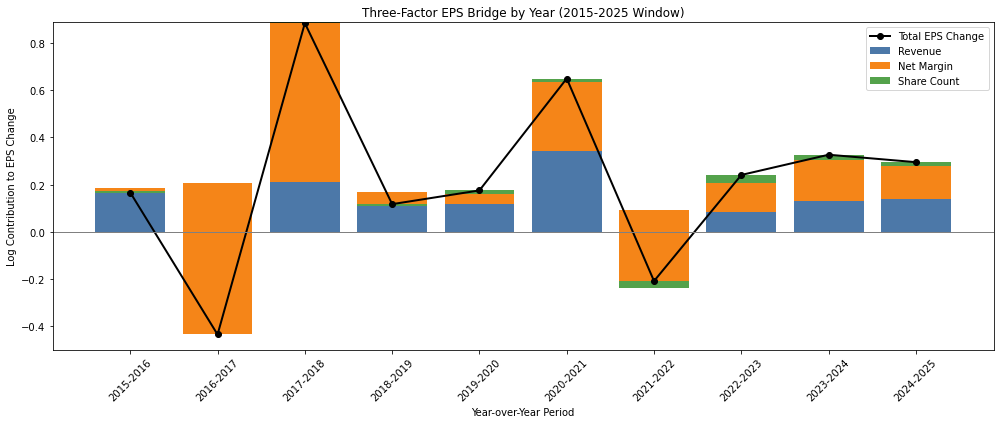

In [3]:
# Chart 1: Year-over-year three-factor EPS bridge for the cleanest modern window.
# Using 2015-2025 avoids the older share-basis break and lines up well with the
# main business questions.
bridge = analysis[analysis["window_label"] == "2015_2025"].copy()
bridge["period"] = pd.Categorical(bridge["period"], categories=bridge["period"], ordered=True)
bridge = bridge.sort_values("period")

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(bridge["period"], bridge["revenue_log_contribution"], label="Revenue", color="#4C78A8")
ax.bar(
    bridge["period"],
    bridge["net_margin_log_contribution"],
    bottom=bridge["revenue_log_contribution"],
    label="Net Margin",
    color="#F58518",
)
ax.bar(
    bridge["period"],
    bridge["share_count_log_contribution"],
    bottom=bridge["revenue_log_contribution"] + bridge["net_margin_log_contribution"],
    label="Share Count",
    color="#54A24B",
)
ax.plot(bridge["period"], bridge["eps_log_change"], color="black", marker="o", linewidth=2, label="Total EPS Change")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Three-Factor EPS Bridge by Year (2015-2025 Window)")
ax.set_ylabel("Log Contribution to EPS Change")
ax.set_xlabel("Year-over-Year Period")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

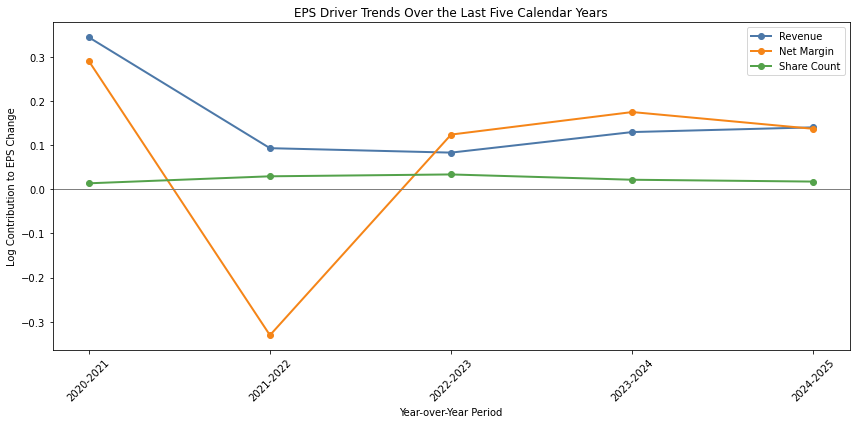

In [4]:
# Chart 2: Rolling 2020-2025 factor view.
# This is the clearest visual for the "most consistent" and "most volatile"
# questions because it isolates the last five calendar years.
rolling = analysis[
    (analysis["window_label"] == "2015_2025")
    & (analysis["from_year"] >= 2020)
    & (analysis["to_year"] <= 2025)
].copy()
rolling["period"] = pd.Categorical(rolling["period"], categories=rolling["period"], ordered=True)
rolling = rolling.sort_values("period")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rolling["period"], rolling["revenue_log_contribution"], marker="o", linewidth=2, label="Revenue", color="#4C78A8")
ax.plot(rolling["period"], rolling["net_margin_log_contribution"], marker="o", linewidth=2, label="Net Margin", color="#F58518")
ax.plot(rolling["period"], rolling["share_count_log_contribution"], marker="o", linewidth=2, label="Share Count", color="#54A24B")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("EPS Driver Trends Over the Last Five Calendar Years")
ax.set_ylabel("Log Contribution to EPS Change")
ax.set_xlabel("Year-over-Year Period")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

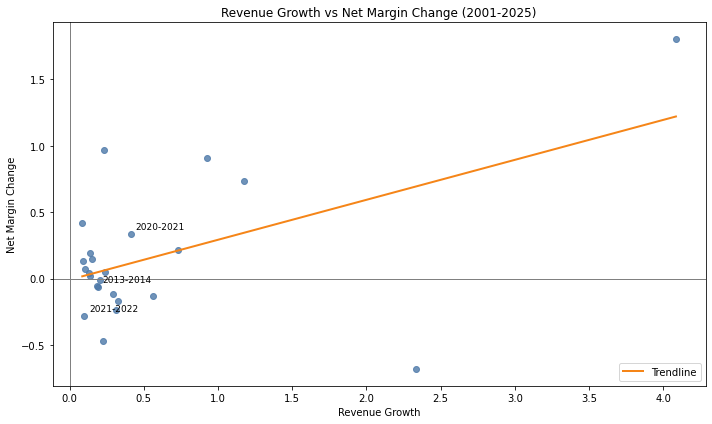

In [5]:
# Chart 3: Revenue growth vs net margin change.
# The fitted line makes it easier to visually discuss whether margin tends to
# expand alongside strong revenue growth, which ties directly to the
# operational-leverage question.
scatter = analysis[analysis["window_label"] == "2001_2025"].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter["revenue_growth"], scatter["net_margin_growth"], color="#4C78A8", alpha=0.8)

for _, row in scatter.iterrows():
    if row["period"] in {"2013-2014", "2020-2021", "2021-2022"}:
        ax.annotate(row["period"], (row["revenue_growth"], row["net_margin_growth"]), xytext=(5, 5), textcoords="offset points", fontsize=9)

# Fit a simple linear trendline for visual guidance.
trend = scatter["revenue_growth"].to_numpy()
coefficients = scatter["net_margin_growth"].to_numpy()
fit = np.polyfit(trend, coefficients, 1)
x_vals = np.linspace(trend.min(), trend.max(), 100)
y_vals = fit[0] * x_vals + fit[1]
ax.plot(x_vals, y_vals, color="#F58518", linewidth=2, label="Trendline")

ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Revenue Growth vs Net Margin Change (2001-2025)")
ax.set_xlabel("Revenue Growth")
ax.set_ylabel("Net Margin Change")
ax.legend()
plt.tight_layout()
plt.show()